<a href="https://colab.research.google.com/github/sanchi1004/EDA-Course-Project/blob/main/Phase2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import pdist, squareform

sns.set_style("whitegrid")

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/bcancer.csv"

df = pd.read_csv(url)

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

print(correlation_matrix)

                               id  radius_mean  texture_mean  perimeter_mean  \
id                       1.000000     0.074626      0.099770        0.073159   
radius_mean              0.074626     1.000000      0.323782        0.997855   
texture_mean             0.099770     0.323782      1.000000        0.329533   
perimeter_mean           0.073159     0.997855      0.329533        1.000000   
area_mean                0.096893     0.987357      0.321086        0.986507   
smoothness_mean         -0.012968     0.170581     -0.023389        0.207278   
compactness_mean         0.000096     0.506124      0.236702        0.556936   
concavity_mean           0.050080     0.676764      0.302418        0.716136   
concave points_mean      0.044158     0.822529      0.293464        0.850977   
symmetry_mean           -0.022114     0.147741      0.071401        0.183027   
fractal_dimension_mean  -0.052511    -0.311631     -0.076437       -0.261477   
radius_se                0.143048     0.

In [6]:
corr_pairs = correlation_matrix.unstack()

corr_pairs = corr_pairs[
    (corr_pairs != 1)
]

corr_pairs = corr_pairs.sort_values(
    ascending=False
)

print("Top Correlations:")
print(corr_pairs.head(10))

Top Correlations:
radius_mean      perimeter_mean     0.997855
perimeter_mean   radius_mean        0.997855
perimeter_worst  radius_worst       0.993708
radius_worst     perimeter_worst    0.993708
area_mean        radius_mean        0.987357
radius_mean      area_mean          0.987357
perimeter_mean   area_mean          0.986507
area_mean        perimeter_mean     0.986507
area_worst       radius_worst       0.984015
radius_worst     area_worst         0.984015
dtype: float64


In [7]:
correlation = df["radius_mean"].corr(
    df["perimeter_mean"]
)

print("Correlation between Radius Mean and Perimeter Mean:",
      correlation)

Correlation between Radius Mean and Perimeter Mean: 0.9978552814938105


Time Series Analysis

In [8]:
dates = pd.date_range(
    start="2020-01-01",
    periods=100,
    freq="D"
)

np.random.seed(23)

values = np.cumsum(
    np.random.randn(100)
) + 100

ts_df = pd.DataFrame({
    "Date": dates,
    "Value": values
})

ts_df.head()

,Date,Value
0,2020-01-01,100.666988
1,2020-01-02,100.692801
2,2020-01-03,99.915182
3,2020-01-04,100.863816
4,2020-01-05,101.565487


In [9]:
ts_df["Date"] = pd.to_datetime(ts_df["Date"])

ts_df.set_index("Date", inplace=True)

print(ts_df.head())

                 Value
Date                  
2020-01-01  100.666988
2020-01-02  100.692801
2020-01-03   99.915182
2020-01-04  100.863816
2020-01-05  101.565487


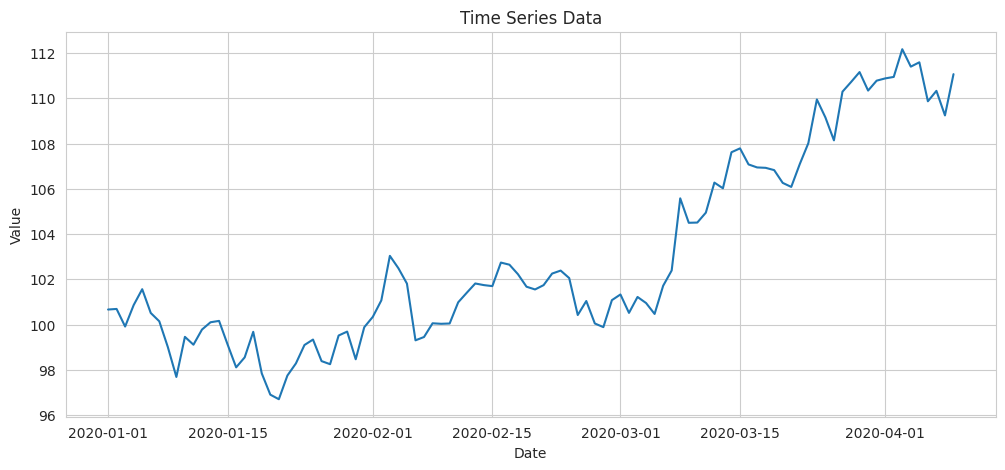

In [10]:
plt.figure(figsize=(12,5))

plt.plot(
    ts_df.index,
    ts_df["Value"]
)

plt.title("Time Series Data")
plt.xlabel("Date")
plt.ylabel("Value")

plt.show()

In [11]:
print(ts_df.loc["2020-01"])

                 Value
Date                  
2020-01-01  100.666988
2020-01-02  100.692801
2020-01-03   99.915182
2020-01-04  100.863816
2020-01-05  101.565487
2020-01-06  100.514406
2020-01-07  100.146858
2020-01-08   99.009398
2020-01-09   97.687250
2020-01-10   99.459509
2020-01-11   99.112050
2020-01-12   99.782190
2020-01-13  100.104461
2020-01-14  100.164804
2020-01-15   99.121354
2020-01-16   98.111412
2020-01-17   98.553149
2020-01-18   99.682026
2020-01-19   97.843958
2020-01-20   96.905189
2020-01-21   96.703349
2020-01-22   97.748720
2020-01-23   98.286882
2020-01-24   99.099001
2020-01-25   99.340107
2020-01-26   98.387597
2020-01-27   98.251331
2020-01-28   99.518579
2020-01-29   99.692213
2020-01-30   98.468958
2020-01-31   99.884278


In [12]:
print(
    ts_df.loc["2020-01-10":"2020-01-20"]
)

                 Value
Date                  
2020-01-10   99.459509
2020-01-11   99.112050
2020-01-12   99.782190
2020-01-13  100.104461
2020-01-14  100.164804
2020-01-15   99.121354
2020-01-16   98.111412
2020-01-17   98.553149
2020-01-18   99.682026
2020-01-19   97.843958
2020-01-20   96.905189


In [13]:
monthly_data = ts_df.resample("ME").mean()

print(monthly_data)

                 Value
Date                  
2020-01-31   99.202687
2020-02-29  101.279305
2020-03-31  106.182116
2020-04-30  110.833841


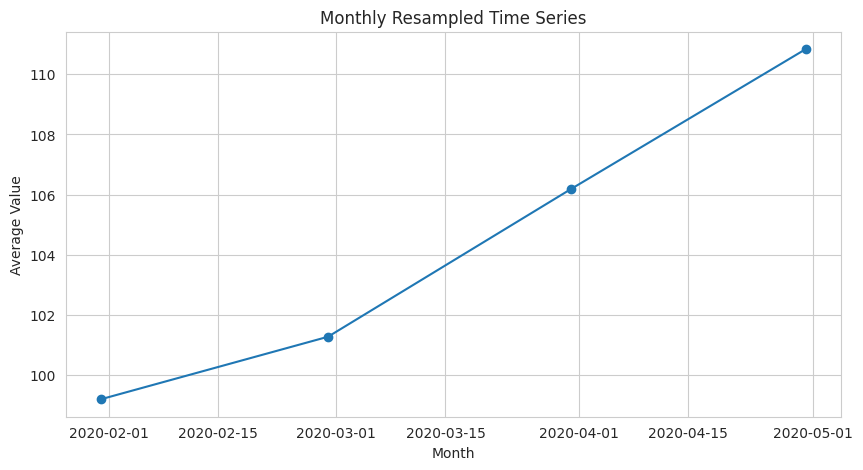

In [14]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_data.index,
    monthly_data["Value"],
    marker="o"
)

plt.title("Monthly Resampled Time Series")
plt.xlabel("Month")
plt.ylabel("Average Value")

plt.show()

In [15]:
df["radius_category"] = pd.qcut(
    df["radius_mean"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [16]:
contingency_table = pd.crosstab(
    df["diagnosis"],
    df["radius_category"]
)

print(contingency_table)

radius_category  Low  Medium  High
diagnosis                         
B                185     149    23
M                  6      39   167


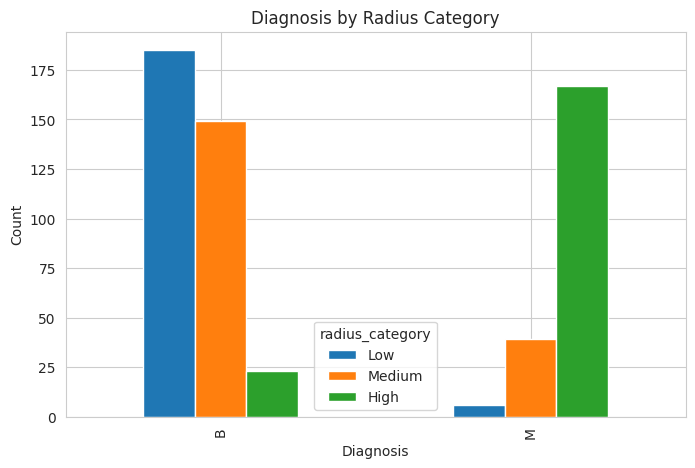

In [17]:
contingency_table.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Diagnosis by Radius Category")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

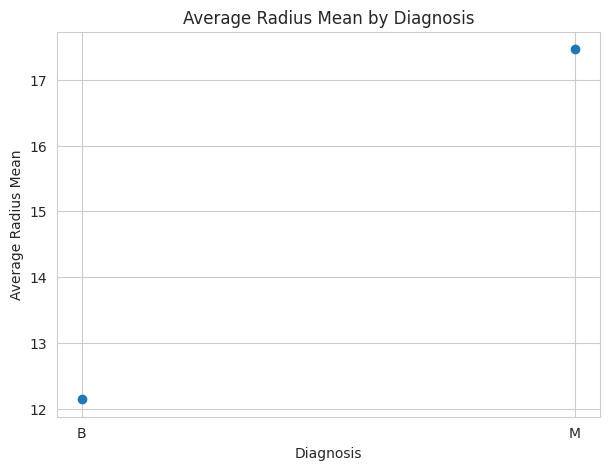

In [18]:
dot_data = df.groupby(
    "diagnosis"
)["radius_mean"].mean()

plt.figure(figsize=(7,5))

plt.plot(
    dot_data.index,
    dot_data.values,
    "o"
)

plt.title("Average Radius Mean by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Average Radius Mean")

plt.show()

Clustering

In [27]:
cluster_df = df.select_dtypes(include=np.number).copy()

cluster_df = cluster_df.drop(
    columns=["diagnosis"],
    errors="ignore"
)

cluster_df = cluster_df.dropna(axis=1, how="all")

cluster_df = cluster_df.fillna(
    cluster_df.median()
)

print("Clustering data shape:", cluster_df.shape)
print("Missing values:", cluster_df.isnull().sum().sum())

Clustering data shape: (569, 31)
Missing values: 0


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(cluster_df)

print("X shape:", X.shape)

X shape: (569, 31)


In [31]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    random_state=23
)

spectral_labels = spectral.fit_predict(X)

print("Spectral Clustering Labels:")
print(spectral_labels)

Spectral Clustering Labels:
[1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 0 1 0 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 1 0 0 1 0 1 0 1 0
 0 1 0 1 1 0 0 1 1 1 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0
 0 1 0 0 0 0 1 1 1 0 1 1 0 0 0 0 1 0 1 0 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0
 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 1 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0
 0 1 0 0 0 1 0 0 1 1 0 1 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 1 1 1 0 0 1 1 0 0
 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 0 1 1 1
 1 1 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0
 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1
 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 1 0 0
 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1

In [32]:
from sklearn.metrics import silhouette_score

print(
    "Spectral Clustering Silhouette Score:",
    silhouette_score(X, spectral_labels)
)

Spectral Clustering Silhouette Score: 0.3311744047327889


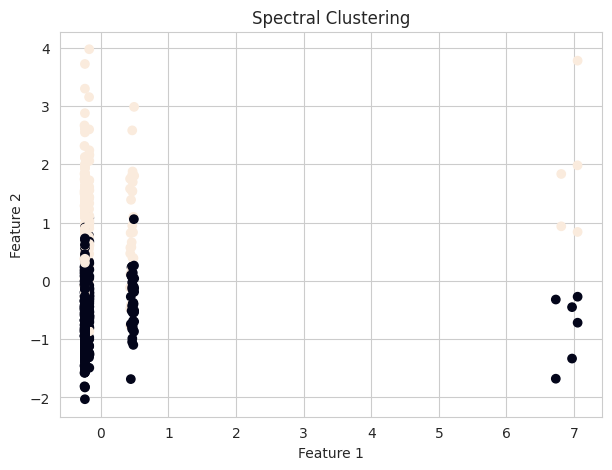

In [33]:
plt.figure(figsize=(7,5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=spectral_labels
)

plt.title("Spectral Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

documents = [
    "machine learning artificial intelligence",
    "deep learning neural networks",
    "machine learning algorithms",
    "football cricket sports players",
    "cricket match sports players",
    "football sports tournament"
]

vectorizer = TfidfVectorizer(
    stop_words="english"
)

X_text = vectorizer.fit_transform(documents)

kmeans_text = KMeans(
    n_clusters=2,
    random_state=23,
    n_init=10
)

text_labels = kmeans_text.fit_predict(X_text)

for document, label in zip(
    documents,
    text_labels
):
    print("Cluster:", label, "|", document)

Cluster: 1 | machine learning artificial intelligence
Cluster: 1 | deep learning neural networks
Cluster: 1 | machine learning algorithms
Cluster: 0 | football cricket sports players
Cluster: 0 | cricket match sports players
Cluster: 0 | football sports tournament


In [35]:
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree

X_mst = X[:50]

distance_matrix = squareform(
    pdist(X_mst)
)

mst = minimum_spanning_tree(
    distance_matrix
)

mst_array = mst.toarray()

print("Minimum Spanning Tree:")
print(mst_array)

Minimum Spanning Tree:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


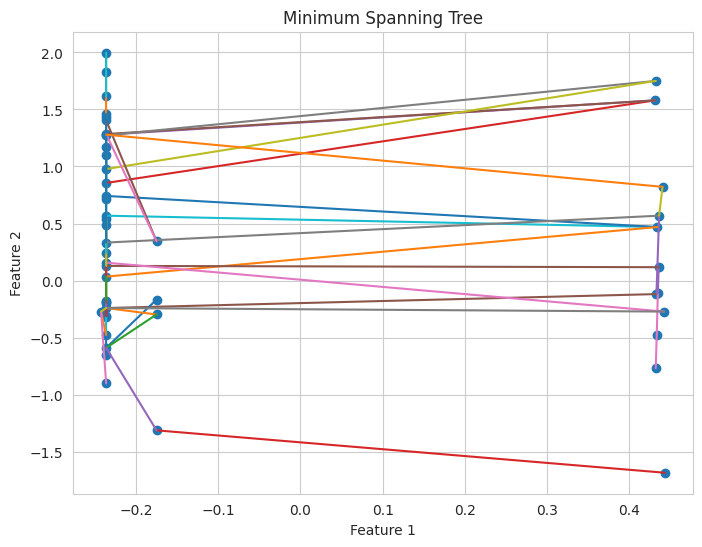

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_mst[:, 0],
    X_mst[:, 1]
)

for i in range(len(mst_array)):
    for j in range(len(mst_array)):
        if mst_array[i, j] > 0:
            plt.plot(
                [X_mst[i, 0], X_mst[j, 0]],
                [X_mst[i, 1], X_mst[j, 1]]
            )

plt.title("Minimum Spanning Tree")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [37]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=2,
    random_state=23
)

gmm_labels = gmm.fit_predict(X)

print("GMM Cluster Labels:")
print(gmm_labels)

GMM Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 0 1 0 0 1 1 1 1 0 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 0 1 1 0 0 1 0 1 0 1 0
 0 1 0 1 1 0 0 1 1 1 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0
 0 1 0 0 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 1
 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 1 0 1
 0 1 0 0 0 1 0 0 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 0 1 0 1 1 1 0 0 0 1 1 0 0
 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 1 1 1 0 1 1 1
 1 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 1 1 1 0 0
 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1
 1 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 1 0 0
 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 

In [38]:
print(
    "GMM Silhouette Score:",
    silhouette_score(X, gmm_labels)
)

GMM Silhouette Score: 0.30790772029801805


In [39]:
print("Cluster Means:")
print(gmm.means_)

print("\nCluster Weights:")
print(gmm.weights_)

print("\nCovariance Matrices:")
print(gmm.covariances_)

Cluster Means:
[[-0.03216876 -0.54432028 -0.29009059 -0.5583849  -0.53228014 -0.27195958
  -0.51452375 -0.59481384 -0.60799373 -0.27720275 -0.08531529 -0.43665309
   0.00110985 -0.43967775 -0.4178974   0.04003744 -0.34652836 -0.32870504
  -0.38187682 -0.04526048 -0.20572992 -0.58187125 -0.31458872 -0.59349574
  -0.55269879 -0.30812596 -0.50966621 -0.5727403  -0.62545856 -0.34057349
  -0.3325062 ]
 [ 0.05329552  0.90180134  0.48060691  0.92510287  0.88185387  0.45056839
   0.85243602  0.98545644  1.00729219  0.45925501  0.14134591  0.72342398
  -0.00183874  0.72843509  0.69235054 -0.06633193  0.57411004  0.54458131
   0.63267352  0.0749852   0.34084256  0.96401382  0.52119412  0.98327268
   0.91568243  0.51048697  0.8443883   0.94888615  1.03622701  0.56424434
   0.55087887]]

Cluster Weights:
[0.62359993 0.37640007]

Covariance Matrices:
[[[ 0.87570651 -0.02228116  0.03505859 ... -0.00710851  0.02571742
    0.02051952]
  [-0.02228116  0.25394268  0.00672061 ...  0.13307799 -0.03797163


In [40]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=2
)

hier_labels = hierarchical.fit_predict(X)

print("Hierarchical Cluster Labels:")
print(hier_labels)

Hierarchical Cluster Labels:
[0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 0 0 0 1 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 0 1 0 0 1 1 0 1 0 0 0 1
 1 0 1 0 0 1 1 0 0 0 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1
 1 0 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1 0 0 1 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 0 0 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 1 0 1 1 1 0 0 1 1 0 0 1 1 1
 1 0 1 1 1 0 1 1 0 0 1 0 1 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 0 0 0
 0 0 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1
 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 

In [41]:
print(
    "Hierarchical Clustering Silhouette Score:",
    silhouette_score(X, hier_labels)
)

Hierarchical Clustering Silhouette Score: 0.32512633539907987


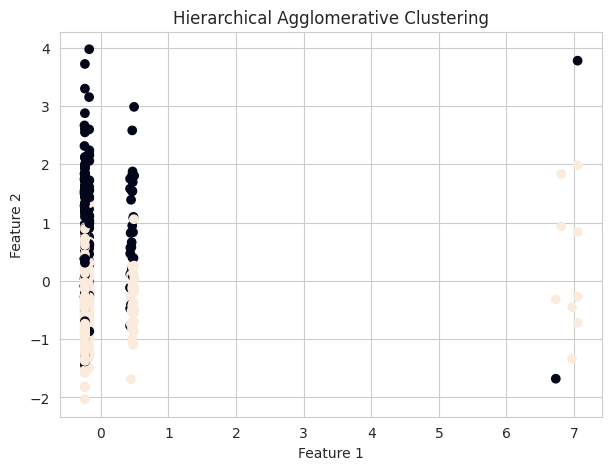

In [42]:
plt.figure(figsize=(7,5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=hier_labels
)

plt.title("Hierarchical Agglomerative Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

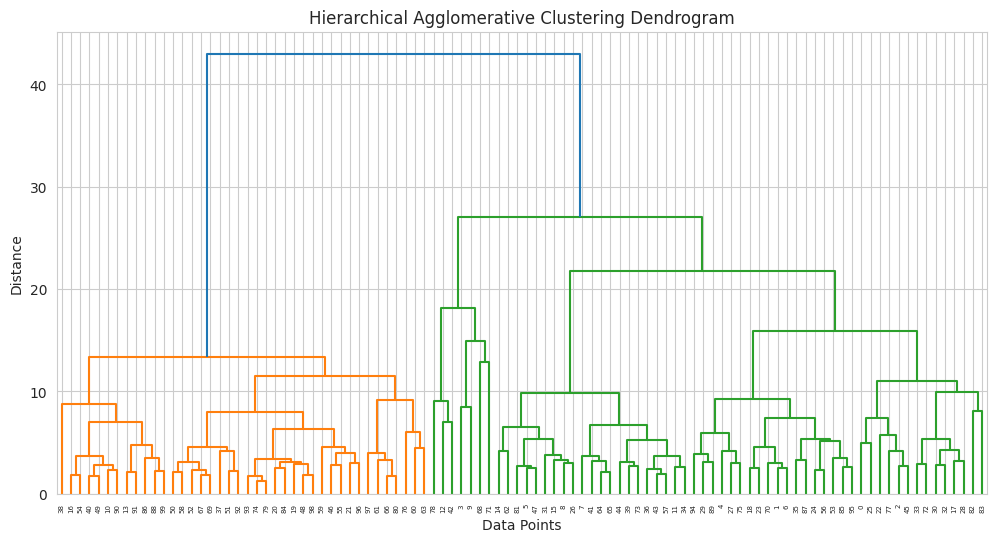

In [43]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(
    X[:100],
    method="ward"
)

plt.figure(figsize=(12,6))

dendrogram(linkage_matrix)

plt.title("Hierarchical Agglomerative Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [44]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=23,
    n_init=10
)

labels = kmeans.fit_predict(X)

centers = kmeans.cluster_centers_

distances = np.linalg.norm(
    X - centers[labels],
    axis=1
)

threshold = np.percentile(
    distances,
    95
)

outliers = distances > threshold

print("Number of Outliers:", outliers.sum())

Number of Outliers: 29


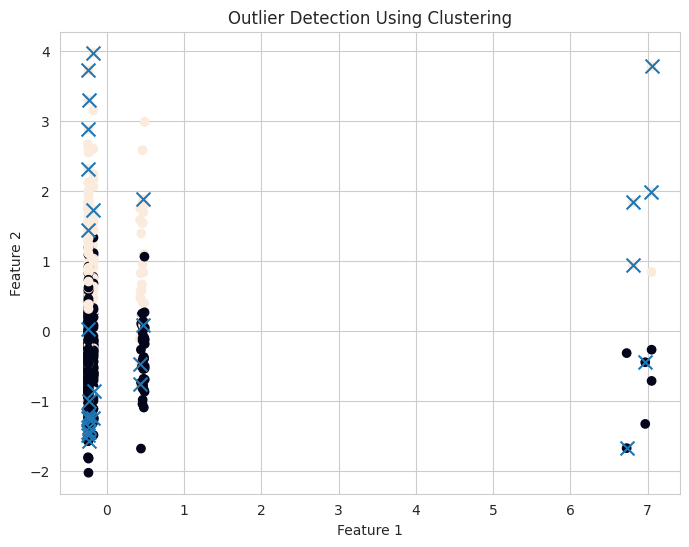

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.scatter(
    X[outliers, 0],
    X[outliers, 1],
    marker="x",
    s=100
)

plt.title("Outlier Detection Using Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

End of Document